In [4]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
DATA_DIR = Path("../data/training")

PATIENT = "patient001"
patient_dir = DATA_DIR / PATIENT

In [6]:
def read_patient_info(patient_dir):
    info = {}

    with open(patient_dir / "Info.cfg", "r") as f:
        for line in f:
            if ":" in line:
                key, value = line.strip().split(":", 1)
                info[key.strip()] = value.strip()

    return info

In [7]:
info = read_patient_info(patient_dir)

ed_frame = int(info["ED"])
es_frame = int(info["ES"])

print(info)

{'ED': '1', 'ES': '12', 'Group': 'DCM', 'Height': '184.0', 'NbFrame': '30', 'Weight': '95.0'}


In [8]:
ed_gt_path = (
    patient_dir /
    f"{PATIENT}_frame{ed_frame:02d}_gt.nii.gz"
)

es_gt_path = (
    patient_dir /
    f"{PATIENT}_frame{es_frame:02d}_gt.nii.gz"
)

ed_gt_img = nib.load(ed_gt_path)
es_gt_img = nib.load(es_gt_path)

ed_gt = ed_gt_img.get_fdata()
es_gt = es_gt_img.get_fdata()

In [9]:
print("ED shape:", ed_gt.shape)
print("ES shape:", es_gt.shape)

print("ED labels:", np.unique(ed_gt))
print("ES labels:", np.unique(es_gt))

print("Voxel spacing:", ed_gt_img.header.get_zooms()[:3])

ED shape: (216, 256, 10)
ES shape: (216, 256, 10)
ED labels: [0. 1. 2. 3.]
ES labels: [0. 1. 2. 3.]
Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))


In [10]:
BACKGROUND = 0
RV = 1
MYOCARDIUM = 2
LV = 3

In [11]:
ed_lv = ed_gt == LV
es_lv = es_gt == LV

ed_rv = ed_gt == RV
es_rv = es_gt == RV

ed_myo = ed_gt == MYOCARDIUM
es_myo = es_gt == MYOCARDIUM

In [12]:
spacing = ed_gt_img.header.get_zooms()[:3]

voxel_volume_mm3 = np.prod(spacing)

print("Voxel spacing:", spacing)
print("Voxel volume:", voxel_volume_mm3, "mm³")

Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))
Voxel volume: 24.414062 mm³


In [13]:
def mask_volume_ml(mask, spacing):
    voxel_volume_mm3 = np.prod(spacing)

    volume_mm3 = np.sum(mask) * voxel_volume_mm3

    return volume_mm3 / 1000

In [14]:
lv_edv = mask_volume_ml(ed_lv, spacing)

print("LV ED volume:", lv_edv, "mL")

LV ED volume: 295.5078125 mL


In [15]:
lv_edv = mask_volume_ml(ed_lv, spacing)
lv_esv = mask_volume_ml(es_lv, spacing)

lv_sv = lv_edv - lv_esv

lv_ef = (lv_sv / lv_edv) * 100

In [16]:
print(f"LV EDV: {lv_edv:.2f} mL")
print(f"LV ESV: {lv_esv:.2f} mL")
print(f"LV SV:  {lv_sv:.2f} mL")
print(f"LV EF:  {lv_ef:.2f}%")

LV EDV: 295.51 mL
LV ESV: 225.61 mL
LV SV:  69.90 mL
LV EF:  23.65%


In [17]:
rv_edv = mask_volume_ml(ed_rv, spacing)
rv_esv = mask_volume_ml(es_rv, spacing)

rv_sv = rv_edv - rv_esv
rv_ef = (rv_sv / rv_edv) * 100

In [18]:
print(f"RV EDV: {rv_edv:.2f} mL")
print(f"RV ESV: {rv_esv:.2f} mL")
print(f"RV SV:  {rv_sv:.2f} mL")
print(f"RV EF:  {rv_ef:.2f}%")

RV EDV: 139.72 mL
RV ESV: 59.55 mL
RV SV:  80.18 mL
RV EF:  57.38%


In [19]:
def ventricular_metrics(ed_gt, es_gt, spacing, label):
    ed_mask = ed_gt == label
    es_mask = es_gt == label

    edv = mask_volume_ml(ed_mask, spacing)
    esv = mask_volume_ml(es_mask, spacing)

    sv = edv - esv
    ef = (sv / edv) * 100

    return {
        "EDV_mL": edv,
        "ESV_mL": esv,
        "SV_mL": sv,
        "EF_percent": ef
    }

In [20]:
lv_metrics = ventricular_metrics(
    ed_gt,
    es_gt,
    spacing,
    LV
)

rv_metrics = ventricular_metrics(
    ed_gt,
    es_gt,
    spacing,
    RV
)

In [21]:
metrics_df = pd.DataFrame(
    {
        "LV": lv_metrics,
        "RV": rv_metrics
    }
).T

metrics_df

,EDV_mL,ESV_mL,SV_mL,EF_percent
LV,295.507812,225.610352,69.897461,23.653338
RV,139.721680,59.545898,80.175781,57.382492


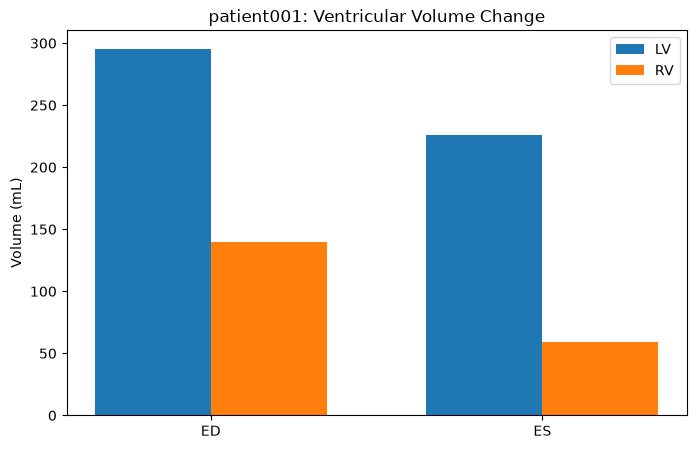

In [22]:
labels = ["ED", "ES"]

lv_values = [
    lv_metrics["EDV_mL"],
    lv_metrics["ESV_mL"]
]

rv_values = [
    rv_metrics["EDV_mL"],
    rv_metrics["ESV_mL"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    lv_values,
    width,
    label="LV"
)

plt.bar(
    x + width / 2,
    rv_values,
    width,
    label="RV"
)

plt.xticks(x, labels)
plt.ylabel("Volume (mL)")
plt.title(f"{PATIENT}: Ventricular Volume Change")
plt.legend()

plt.show()

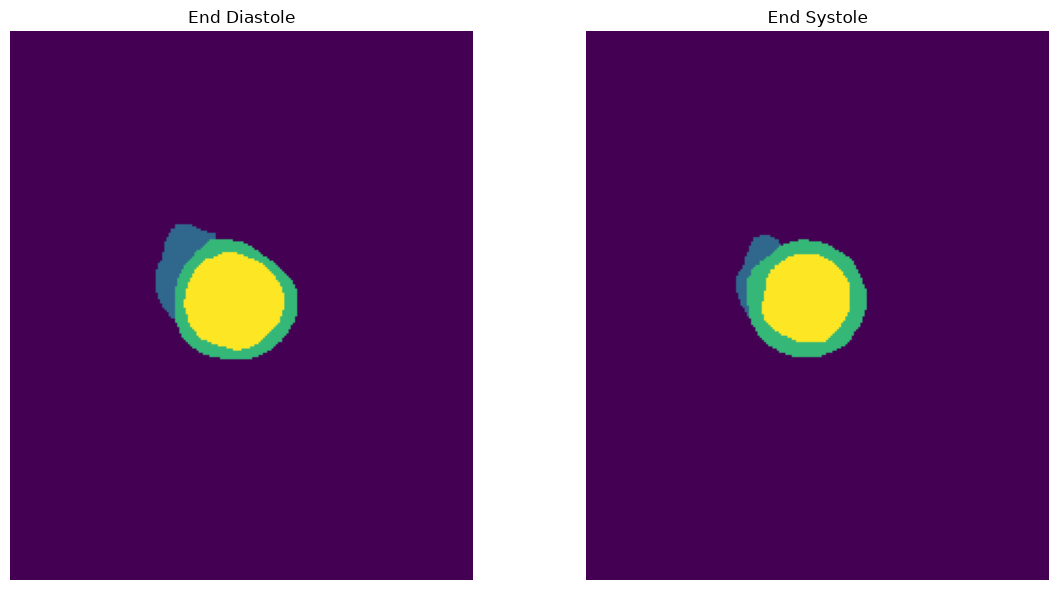

In [23]:
z = ed_gt.shape[2] // 2

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 6)
)

axes[0].imshow(
    ed_gt[:, :, z].T,
    origin="lower"
)
axes[0].set_title("End Diastole")
axes[0].axis("off")

axes[1].imshow(
    es_gt[:, :, z].T,
    origin="lower"
)
axes[1].set_title("End Systole")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [24]:
myo_ed_volume = mask_volume_ml(ed_myo, spacing)
myo_es_volume = mask_volume_ml(es_myo, spacing)

print("Myocardial volume ED:", myo_ed_volume)
print("Myocardial volume ES:", myo_es_volume)

Myocardial volume ED: 164.2578125
Myocardial volume ES: 195.068359375


In [25]:
print(f"""
Patient: {PATIENT}
Group: {info.get("Group")}

LEFT VENTRICLE
---------------
EDV: {lv_metrics["EDV_mL"]:.1f} mL
ESV: {lv_metrics["ESV_mL"]:.1f} mL
SV:  {lv_metrics["SV_mL"]:.1f} mL
EF:  {lv_metrics["EF_percent"]:.1f} %

RIGHT VENTRICLE
----------------
EDV: {rv_metrics["EDV_mL"]:.1f} mL
ESV: {rv_metrics["ESV_mL"]:.1f} mL
SV:  {rv_metrics["SV_mL"]:.1f} mL
EF:  {rv_metrics["EF_percent"]:.1f} %
""")


Patient: patient001
Group: DCM

LEFT VENTRICLE
---------------
EDV: 295.5 mL
ESV: 225.6 mL
SV:  69.9 mL
EF:  23.7 %

RIGHT VENTRICLE
----------------
EDV: 139.7 mL
ESV: 59.5 mL
SV:  80.2 mL
EF:  57.4 %

